In [8]:
#Scrape quotes and authors
import requests
from bs4 import BeautifulSoup

url = "https://quotes.toscrape.com/"
response = requests.get(url)
response.encoding = 'utf-8'
soup = BeautifulSoup(response.text, "html.parser")

quotes = soup.find_all("div", class_="quote")
print(len(quotes))

10


In [10]:
#show us where the quote text, author, and tags live in the HTML.
first_quote = quotes[0]
print(first_quote.prettify())

<div class="quote" itemscope="" itemtype="http://schema.org/CreativeWork">
 <span class="text" itemprop="text">
  “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
 </span>
 <span>
  by
  <small class="author" itemprop="author">
   Albert Einstein
  </small>
  <a href="/author/Albert-Einstein">
   (about)
  </a>
 </span>
 <div class="tags">
  Tags:
  <meta class="keywords" content="change,deep-thoughts,thinking,world" itemprop="keywords"/>
  <a class="tag" href="/tag/change/page/1/">
   change
  </a>
  <a class="tag" href="/tag/deep-thoughts/page/1/">
   deep-thoughts
  </a>
  <a class="tag" href="/tag/thinking/page/1/">
   thinking
  </a>
  <a class="tag" href="/tag/world/page/1/">
   world
  </a>
 </div>
</div>



In [11]:
# Extract the quote text, author name, and tags from the first quote
text = first_quote.find("span", class_="text").text
author = first_quote.find("small", class_="author").text
tags = [tag.text for tag in first_quote.find_all("a", class_="tag")]  # a quote can have multiple tags

print("Text:", text)
print("Author:", author)
print("Tags:", tags)

Text: “The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”
Author: Albert Einstein
Tags: ['change', 'deep-thoughts', 'thinking', 'world']


In [12]:
#scrape all quotes across all pages:
import time

all_quotes = []

for page_num in range(1, 11):  # pages 1 to 10
    page_url = f"https://quotes.toscrape.com/page/{page_num}/"
    response = requests.get(page_url)
    response.encoding = 'utf-8'
    soup = BeautifulSoup(response.text, "html.parser")
    quotes = soup.find_all("div", class_="quote")

    for quote in quotes:
        text = quote.find("span", class_="text").text
        author = quote.find("small", class_="author").text
        tags = [tag.text for tag in quote.find_all("a", class_="tag")]

        all_quotes.append({
            "Quote": text,
            "Author": author,
            "Tags": ", ".join(tags)  # join tags into one string for easy CSV storage
        })

    time.sleep(0.3)  # polite pause between requests

print(len(all_quotes), "quotes collected")
print(all_quotes[0])

100 quotes collected
{'Quote': '“The world as we have created it is a process of our thinking. It cannot be changed without changing our thinking.”', 'Author': 'Albert Einstein', 'Tags': 'change, deep-thoughts, thinking, world'}


In [13]:
#All 100 quotes collected. Let's save this and turn it into a DataFrame.
import pandas as pd

quotes_df = pd.DataFrame(all_quotes)
quotes_df.to_csv("quotes_data.csv", index=False)
print("Saved:", len(quotes_df), "rows")
quotes_df.head()

Saved: 100 rows


,Quote,Author,Tags
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world"
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices"
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles"
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor"
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational"


In [14]:
#Run Sentiment Analysis
#install/setup:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...


In [15]:
#test on one example:
test_score = sia.polarity_scores("I absolutely loved this book, it was amazing!")
print(test_score)

{'neg': 0.0, 'neu': 0.376, 'pos': 0.624, 'compound': 0.8513}


In [16]:
#Apply sentiment analysis to all 100 quotes
def get_sentiment(text):
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

quotes_df["Sentiment"] = quotes_df["Quote"].apply(get_sentiment)
quotes_df["Sentiment_Score"] = quotes_df["Quote"].apply(lambda x: sia.polarity_scores(x)["compound"])

quotes_df.head(10)

,Quote,Author,Tags,Sentiment,Sentiment_Score
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world",Positive,0.2500
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices",Positive,0.4404
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles",Negative,-0.4717
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor",Negative,-0.4774
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational",Positive,0.2516
5,“Try not to become a man of success. Rather be...,Albert Einstein,"adulthood, success, value",Positive,0.5719
6,“It is better to be hated for what you are tha...,André Gide,"life, love",Positive,0.3818
7,"“I have not failed. I've just found 10,000 way...",Thomas A. Edison,"edison, failure, inspirational, paraphrased",Positive,0.4023
8,“A woman is like a tea bag; you never know how...,Eleanor Roosevelt,misattributed-eleanor-roosevelt,Negative,-0.0521
9,"“A day without sunshine is like, you know, nig...",Steve Martin,"humor, obvious, simile",Negative,-0.5773


In [17]:
#Overall sentiment breakdown
print(quotes_df["Sentiment"].value_counts())

Sentiment
Positive    48
Negative    28
Neutral     24
Name: count, dtype: int64


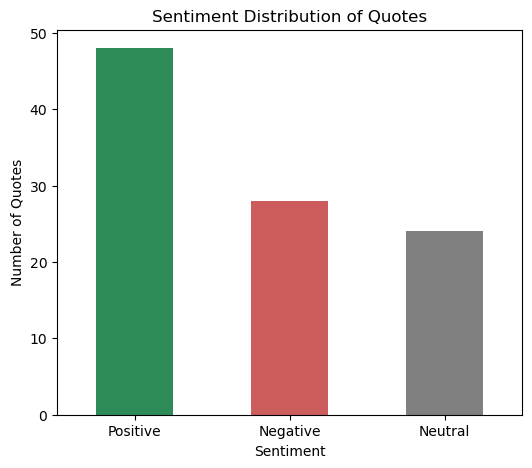

In [18]:
#Visualize it
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
quotes_df["Sentiment"].value_counts().plot(kind="bar", color=["seagreen", "indianred", "gray"])
plt.title("Sentiment Distribution of Quotes")
plt.xlabel("Sentiment")
plt.ylabel("Number of Quotes")
plt.xticks(rotation=0)
plt.show()

In [19]:
# Group quotes by author and calculate their average sentiment score
# This shows which authors tend to have more positive vs negative quotes in our sample
author_sentiment = quotes_df.groupby("Author")["Sentiment_Score"].mean().sort_values(ascending=False)

print("Most positive authors (avg):")
print(author_sentiment.head(5))

print("\nMost negative authors (avg):")
print(author_sentiment.tail(5))

Most positive authors (avg):
Author
Elie Wiesel      0.9484
Pablo Neruda     0.9447
J.D. Salinger    0.8885
James Baldwin    0.8316
John Lennon      0.7684
Name: Sentiment_Score, dtype: float64

Most negative authors (avg):
Author
Steve Martin          -0.5773
J.M. Barrie           -0.5994
Ralph Waldo Emerson   -0.6589
Jim Henson            -0.7184
Jimi Hendrix          -0.8176
Name: Sentiment_Score, dtype: float64


In [20]:
#quick check:
print(quotes_df["Author"].value_counts().head(10))

Author
Albert Einstein      10
J.K. Rowling          9
Marilyn Monroe        7
Dr. Seuss             6
Mark Twain            6
C.S. Lewis            5
Jane Austen           5
Bob Marley            3
Eleanor Roosevelt     2
Charles Bukowski      2
Name: count, dtype: int64


In [21]:
#redo this properly, only using authors with enough quotes:
# Only trust averages for authors with at least 3 quotes in our sample
author_counts = quotes_df["Author"].value_counts()
reliable_authors = author_counts[author_counts >= 3].index

reliable_df = quotes_df[quotes_df["Author"].isin(reliable_authors)]
reliable_sentiment = reliable_df.groupby("Author")["Sentiment_Score"].mean().sort_values(ascending=False)

print(reliable_sentiment)

Author
J.K. Rowling       0.404756
Marilyn Monroe     0.358514
C.S. Lewis         0.345820
Jane Austen        0.297300
Bob Marley         0.207000
Mark Twain         0.130800
Albert Einstein    0.129440
Dr. Seuss         -0.110667
Name: Sentiment_Score, dtype: float64
